# Notebook 10 — Full Evaluation Story

**Inputs:** `outputs/final_model.pkl`, `outputs/test.parquet`, all model pkl files  
**Outputs:** `outputs/optimal_threshold.txt`, evaluation charts

**Carried-forward context:**
- LR and RF models (notebook 07) were trained on **scaled** features → apply `scaler.pkl` before predicting
- XGB, LGBM (notebook 08) and stacking bundle (notebook 09) use **raw** features
- `stacking_model.pkl` is a dict bundle: `{meta_learner, rf_full, xgb_full, lgbm_full, feature_cols, meta_name}`
- Column names normalised at load time (spaces/hyphens → underscores)

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
print("Project root:", ROOT)

Project root: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction


In [2]:
def load_split(path):
    df = pd.read_parquet(path)
    df.columns = [c.replace(" ", "_").replace("-", "_") for c in df.columns]
    return df

test = load_split(OUTPUTS / "test.parquet")
TARGET       = "is_churn"
FEATURE_COLS = [c for c in test.columns if c not in ("msno", TARGET)]

X_test = test[FEATURE_COLS].values.astype(np.float32)
y_test = test[TARGET].values

# Scaled features for LR and RF (trained on StandardScaler output in notebook 07)
scaler     = joblib.load(OUTPUTS / "scaler.pkl")
X_test_sc  = scaler.transform(X_test)

print("Test set : %s rows | churn=%.2f%%" % (f"{len(X_test):,}", y_test.mean()*100))
print("Features : %d" % len(FEATURE_COLS))

Test set : 125,272 rows | churn=8.77%
Features : 35


In [3]:
# Load all models
lr_model       = joblib.load(OUTPUTS / "lr_model.pkl")    # needs scaled features
rf_model       = joblib.load(OUTPUTS / "rf_model.pkl")    # needs scaled features
xgb_model      = joblib.load(OUTPUTS / "xgb_model.pkl")   # raw features, trained on train+val
lgbm_model     = joblib.load(OUTPUTS / "lgbm_model.pkl")  # raw features, trained on train+val
stack_bundle   = joblib.load(OUTPUTS / "stacking_model.pkl")

# Generate test probabilities for every model
lr_proba   = lr_model.predict_proba(X_test_sc)[:, 1]
rf_proba   = rf_model.predict_proba(X_test_sc)[:, 1]
xgb_proba  = xgb_model.predict_proba(X_test)[:, 1]
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]

# Stacking: base models in the bundle were trained on train only (no val leakage)
X_meta_test  = np.column_stack([
    stack_bundle["rf_full"].predict_proba(X_test)[:, 1],
    stack_bundle["xgb_full"].predict_proba(X_test)[:, 1],
    stack_bundle["lgbm_full"].predict_proba(X_test)[:, 1],
])
stack_proba = stack_bundle["meta_learner"].predict_proba(X_meta_test)[:, 1]

# Identify which model is the final model
final_txt       = (OUTPUTS / "final_model_name.txt").read_text()
final_model_name = next(l for l in final_txt.splitlines()
                        if l.startswith("final_model=")).split("=", 1)[1].strip()

proba_map = {
    "Logistic Regression": lr_proba,
    "Random Forest":        rf_proba,
    "XGBoost":              xgb_proba,
    "LightGBM":             lgbm_proba,
    "Stacking Ensemble":    stack_proba,
}
final_proba = proba_map[final_model_name]

print("Final model selected  :", final_model_name)
print("Test AUC (final model): %.4f" % roc_auc_score(y_test, final_proba))

# Print AUC for all models
print("\nAll model test AUCs:")
for name, proba in proba_map.items():
    marker = " <-- FINAL" if name == final_model_name else ""
    print("  %-22s: %.4f%s" % (name, roc_auc_score(y_test, proba), marker))

Final model selected  : XGBoost
Test AUC (final model): 0.9779

All model test AUCs:
  Logistic Regression   : 0.9268
  Random Forest         : 0.9756


  XGBoost               : 0.9779 <-- FINAL
  LightGBM              : 0.9789
  Stacking Ensemble     : 0.9773


## Section 1 — ROC Curves (All Models)

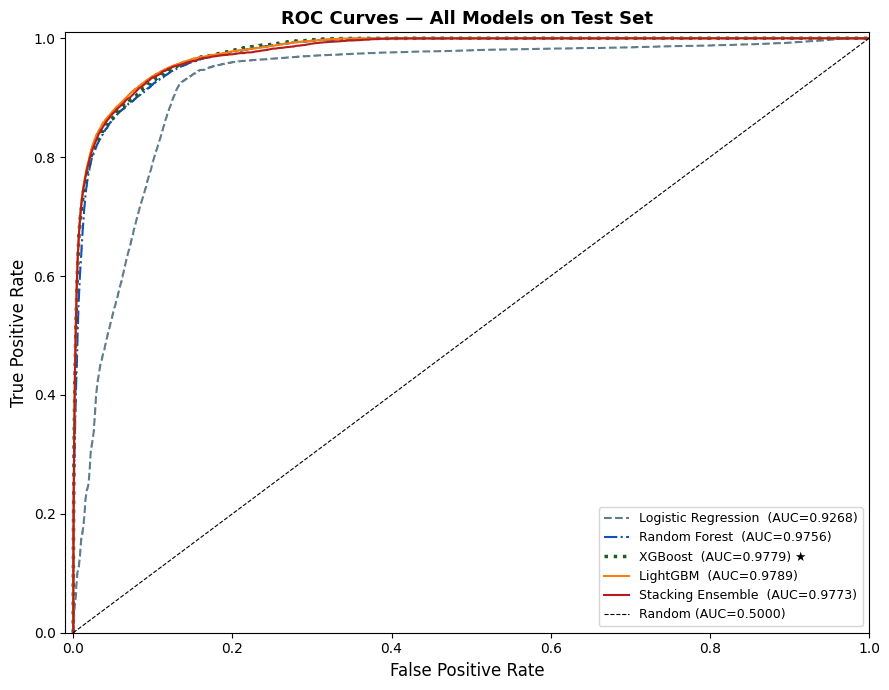

Saved: outputs/10_roc_curves_all.png


In [4]:
model_styles = [
    ("Logistic Regression", lr_proba,   "#607D8B", "--"),
    ("Random Forest",        rf_proba,   "#0F52BA", "-."),
    ("XGBoost",              xgb_proba,  "#1B5E20", ":"),
    ("LightGBM",             lgbm_proba, "#F57F17", "-"),
    ("Stacking Ensemble",    stack_proba,"#B71C1C", "-"),
]

fig, ax = plt.subplots(figsize=(9, 7))
for name, proba, color, ls in model_styles:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    lw = 2.5 if name == final_model_name else 1.5
    label = "%s  (AUC=%.4f)%s" % (name, auc, " ★" if name == final_model_name else "")
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=lw, label=label)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random (AUC=0.5000)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models on Test Set", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim(-0.01, 1.0)
ax.set_ylim(0.0, 1.01)
plt.tight_layout()
plt.savefig(OUTPUTS / "10_roc_curves_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/10_roc_curves_all.png")

## Section 2 — Precision-Recall Curve (Final Model)

**Why the PR curve matters for imbalanced classes:**  
ROC-AUC can be overly optimistic when the negative class dominates (8.77% churn here). The True Negative Rate (specificity) term inflates ROC-AUC even for poor minority-class predictions. The PR curve ignores true negatives entirely and focuses exclusively on how well the model identifies the positive (churn) class — precision tells you how reliable your churn alerts are; recall tells you how many churners you actually catch.

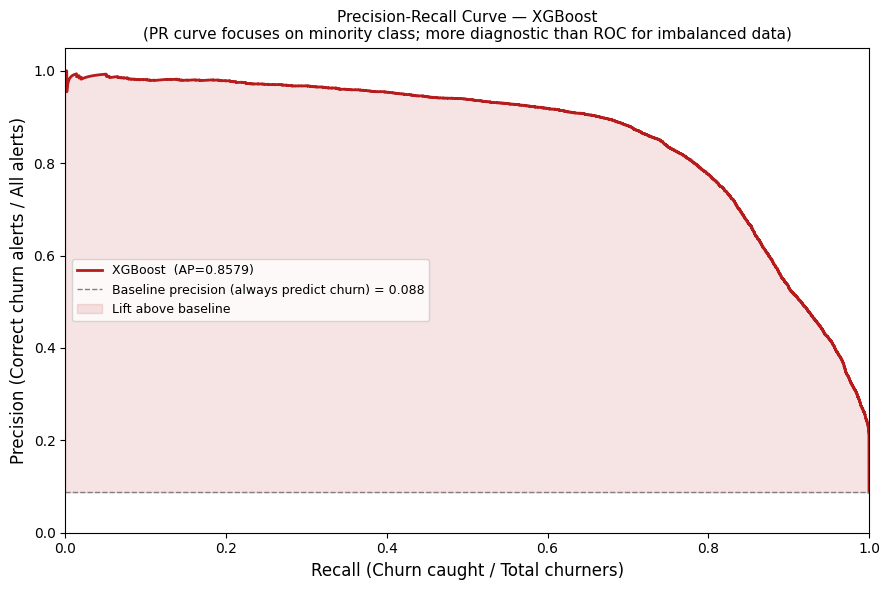

Saved: outputs/10_pr_curve.png


In [5]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, final_proba)
ap = average_precision_score(y_test, final_proba)
baseline_precision = y_test.mean()  # always-predict-positive precision

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall, precision, color="#B71C1C", linewidth=2,
        label="%s  (AP=%.4f)" % (final_model_name, ap))
ax.axhline(baseline_precision, color="gray", linestyle="--", linewidth=1,
           label="Baseline precision (always predict churn) = %.3f" % baseline_precision)
ax.fill_between(recall, precision, baseline_precision,
                where=(precision > baseline_precision),
                alpha=0.12, color="#B71C1C", label="Lift above baseline")
ax.set_xlabel("Recall (Churn caught / Total churners)", fontsize=12)
ax.set_ylabel("Precision (Correct churn alerts / All alerts)", fontsize=12)
ax.set_title("Precision-Recall Curve — %s\n" % final_model_name +
             "(PR curve focuses on minority class; more diagnostic than ROC for imbalanced data)",
             fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUTPUTS / "10_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/10_pr_curve.png")

## Section 3 — Confusion Matrix at Default Threshold (0.5)

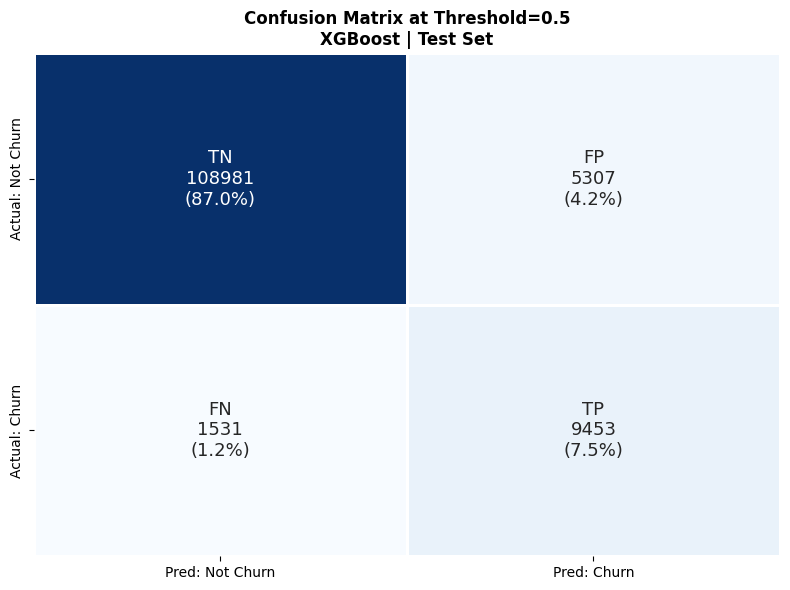

Saved: outputs/10_confusion_matrix.png

Business interpretation at threshold=0.5:
  TP=9453 : Churners correctly identified → target for retention campaigns
  FP=5307 : Loyal customers mis-labelled as churners → retention effort wasted
  FN=1531 : Churners we missed → lost revenue (most costly error)
  TN=108981 : Loyal customers correctly left alone → no action needed


In [6]:
DEFAULT_THRESHOLD = 0.5
y_pred_default = (final_proba >= DEFAULT_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_default)
tn, fp, fn, tp = cm.ravel()
total = len(y_test)

# Annotation: counts + percentages
cm_labels = np.array([
    ["TN\n%d\n(%.1f%%)" % (tn, tn/total*100),
     "FP\n%d\n(%.1f%%)" % (fp, fp/total*100)],
    ["FN\n%d\n(%.1f%%)" % (fn, fn/total*100),
     "TP\n%d\n(%.1f%%)" % (tp, tp/total*100)]
])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=cm_labels, fmt="", cmap="Blues", ax=ax,
            xticklabels=["Pred: Not Churn", "Pred: Churn"],
            yticklabels=["Actual: Not Churn", "Actual: Churn"],
            linewidths=1, linecolor="white", cbar=False, annot_kws={"size": 13})
ax.set_title("Confusion Matrix at Threshold=0.5\n%s | Test Set" % final_model_name,
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "10_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/10_confusion_matrix.png")

print("\nBusiness interpretation at threshold=0.5:")
print("  TP=%d : Churners correctly identified → target for retention campaigns" % tp)
print("  FP=%d : Loyal customers mis-labelled as churners → retention effort wasted" % fp)
print("  FN=%d : Churners we missed → lost revenue (most costly error)" % fn)
print("  TN=%d : Loyal customers correctly left alone → no action needed" % tn)

## Section 4 — Threshold Optimisation

Business cost model:
- **FN cost = $120** per missed churner (estimated monthly subscription value lost)
- **FP cost = $15** per false alarm (retention discount or free trial offer)

Lowering the threshold catches more churners (higher recall) at the expense of more false alarms. The optimal threshold minimises total business cost.

In [7]:
FN_COST = 120
FP_COST = 15

thresholds = np.arange(0.10, 0.91, 0.05)
results = []

for thr in thresholds:
    pred = (final_proba >= thr).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, pred).ravel()
    cost = fn_t * FN_COST + fp_t * FP_COST
    f1   = f1_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    results.append({
        "threshold": round(thr, 2),
        "tp": tp_t, "fp": fp_t, "fn": fn_t, "tn": tn_t,
        "business_cost": cost,
        "f1": f1, "precision": prec, "recall": rec
    })

results_df = pd.DataFrame(results)

# Identify optimal threshold
opt_idx  = results_df["business_cost"].idxmin()
opt_thr  = results_df.loc[opt_idx, "threshold"]
opt_cost = results_df.loc[opt_idx, "business_cost"]

print("Threshold sweep:")
print(results_df[["threshold","business_cost","f1","precision","recall"]].to_string(index=False))
print("\nOptimal threshold : %.2f" % opt_thr)
print("Business cost     : $%s" % f"{int(opt_cost):,}")

Threshold sweep:
 threshold  business_cost       f1  precision   recall
      0.10         373275 0.479857   0.317735 0.979789
      0.15         317565 0.531916   0.366706 0.968044
      0.20         289800 0.567771   0.403641 0.956846
      0.25         278355 0.592398   0.431573 0.944283
      0.30         268710 0.615740   0.459384 0.933449
      0.35         263340 0.641322   0.492674 0.918427
      0.40         261705 0.672369   0.537309 0.898125
      0.45         259830 0.707214   0.591759 0.878642
      0.50         263325 0.734385   0.640447 0.860615
      0.55         268770 0.755422   0.682925 0.845138
      0.60         274545 0.770455   0.716759 0.832848
      0.65         284580 0.780632   0.745690 0.819009
      0.70         298110 0.786653   0.770217 0.803806
      0.75         312990 0.790218   0.792025 0.788420
      0.80         332640 0.792495   0.817337 0.769119
      0.85         358590 0.790729   0.841867 0.745448
      0.90         400425 0.782499   0.872815 0.

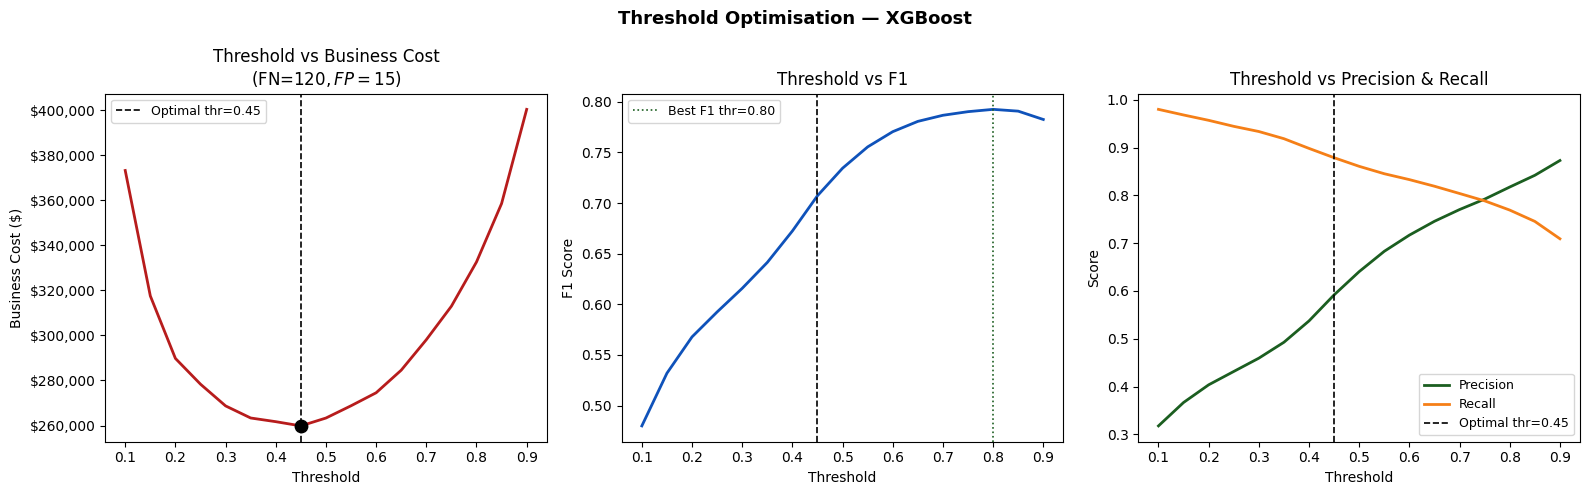

Saved: outputs/10_threshold_optimisation.png
Saved: outputs/optimal_threshold.txt


In [8]:
# Three-panel threshold plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Threshold Optimisation — %s" % final_model_name,
             fontsize=13, fontweight="bold")

thr_vals  = results_df["threshold"]
cost_vals = results_df["business_cost"]

# Panel 1: Business cost
ax = axes[0]
ax.plot(thr_vals, cost_vals, color="#B71C1C", linewidth=2)
ax.axvline(opt_thr, color="black", linestyle="--", linewidth=1.2,
           label="Optimal thr=%.2f" % opt_thr)
ax.scatter([opt_thr], [opt_cost], color="black", s=80, zorder=5)
ax.set_xlabel("Threshold")
ax.set_ylabel("Business Cost ($)")
ax.set_title("Threshold vs Business Cost\n(FN=$%d, FP=$%d)" % (FN_COST, FP_COST))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))
ax.legend(fontsize=9)

# Panel 2: F1
ax = axes[1]
ax.plot(thr_vals, results_df["f1"], color="#0F52BA", linewidth=2)
ax.axvline(opt_thr, color="black", linestyle="--", linewidth=1.2)
best_f1_thr = results_df.loc[results_df["f1"].idxmax(), "threshold"]
ax.axvline(best_f1_thr, color="#1B5E20", linestyle=":", linewidth=1.2,
           label="Best F1 thr=%.2f" % best_f1_thr)
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("Threshold vs F1")
ax.legend(fontsize=9)

# Panel 3: Precision & Recall
ax = axes[2]
ax.plot(thr_vals, results_df["precision"], color="#1B5E20", linewidth=2, label="Precision")
ax.plot(thr_vals, results_df["recall"],    color="#F57F17", linewidth=2, label="Recall")
ax.axvline(opt_thr, color="black", linestyle="--", linewidth=1.2,
           label="Optimal thr=%.2f" % opt_thr)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold vs Precision & Recall")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS / "10_threshold_optimisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/10_threshold_optimisation.png")

# Save optimal threshold
opt_row = results_df.loc[opt_idx]
(OUTPUTS / "optimal_threshold.txt").write_text(
    "optimal_threshold=%.2f\n"
    "business_cost=%d\n"
    "fn_cost_per_unit=%d\n"
    "fp_cost_per_unit=%d\n"
    "f1=%.4f\nprecision=%.4f\nrecall=%.4f\n" % (
        opt_thr, int(opt_cost), FN_COST, FP_COST,
        opt_row["f1"], opt_row["precision"], opt_row["recall"]
    )
)
print("Saved: outputs/optimal_threshold.txt")

## Section 5 — Final Report

In [9]:
# Metrics at optimal threshold
y_pred_opt = (final_proba >= opt_thr).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

# Metrics at default threshold for comparison
cost_default = fn * FN_COST + fp * FP_COST

print("=" * 60)
print("FINAL EVALUATION REPORT")
print("Model      : %s" % final_model_name)
print("Test set   : %s customers | %.2f%% churn rate" % (
    f"{len(y_test):,}", y_test.mean()*100))
print("=" * 60)

print("\n--- At Threshold = 0.50 (default) ---")
print("  ROC-AUC   : %.4f" % roc_auc_score(y_test, final_proba))
print("  F1        : %.4f" % f1_score(y_test, y_pred_default))
print("  Precision : %.4f" % precision_score(y_test, y_pred_default))
print("  Recall    : %.4f" % recall_score(y_test, y_pred_default))
print("  TP=%d  FP=%d  FN=%d  TN=%d" % (tp, fp, fn, tn))
print("  Business cost : $%s" % f"{int(cost_default):,}")

print("\n--- At Threshold = %.2f (optimal business cost) ---" % opt_thr)
print("  ROC-AUC   : %.4f" % roc_auc_score(y_test, final_proba))
print("  F1        : %.4f" % f1_score(y_test, y_pred_opt))
print("  Precision : %.4f" % precision_score(y_test, y_pred_opt))
print("  Recall    : %.4f" % recall_score(y_test, y_pred_opt))
print("  TP=%d  FP=%d  FN=%d  TN=%d" % (tp_o, fp_o, fn_o, tn_o))
print("  Business cost : $%s" % f"{int(opt_cost):,}")

savings = cost_default - opt_cost
pct     = savings / cost_default * 100
print("\n--- Threshold Optimisation Benefit ---")
print("  Cost at 0.50      : $%s" % f"{int(cost_default):,}")
print("  Cost at %.2f      : $%s" % (opt_thr, f"{int(opt_cost):,}"))
if savings > 0:
    print("  Savings           : $%s  (%.1f%% reduction)" % (f"{int(savings):,}", pct))
else:
    print("  Note: default threshold is already near-optimal for this cost structure.")

print("\n--- Classification Report at Optimal Threshold ---")
print(classification_report(y_test, y_pred_opt, target_names=["Not Churn", "Churn"]))

FINAL EVALUATION REPORT
Model      : XGBoost
Test set   : 125,272 customers | 8.77% churn rate

--- At Threshold = 0.50 (default) ---
  ROC-AUC   : 0.9779
  F1        : 0.7344
  Precision : 0.6404


  Recall    : 0.8606
  TP=9453  FP=5307  FN=1531  TN=108981
  Business cost : $263,325

--- At Threshold = 0.45 (optimal business cost) ---
  ROC-AUC   : 0.9779
  F1        : 0.7072
  Precision : 0.5918
  Recall    : 0.8786
  TP=9651  FP=6658  FN=1333  TN=107630
  Business cost : $259,830

--- Threshold Optimisation Benefit ---
  Cost at 0.50      : $263,325
  Cost at 0.45      : $259,830
  Savings           : $3,495  (1.3% reduction)

--- Classification Report at Optimal Threshold ---
              precision    recall  f1-score   support

   Not Churn       0.99      0.94      0.96    114288
       Churn       0.59      0.88      0.71     10984

    accuracy                           0.94    125272
   macro avg       0.79      0.91      0.84    125272
weighted avg       0.95      0.94      0.94    125272



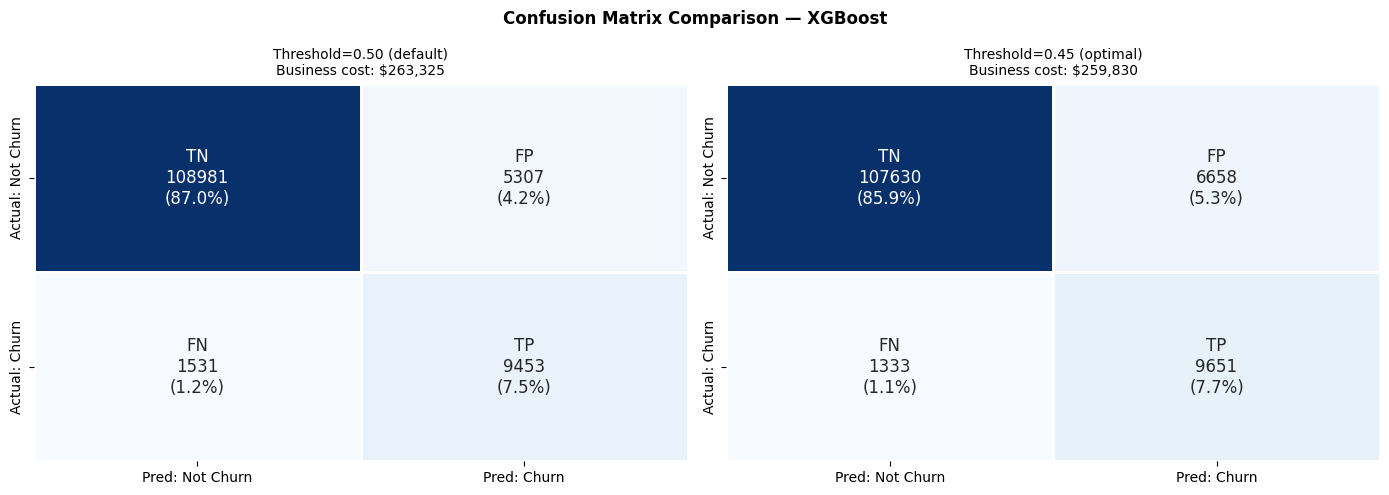

Saved: outputs/10_confusion_matrix_comparison.png


In [10]:
# Confusion matrix at optimal threshold
cm_opt_labels = np.array([
    ["TN\n%d\n(%.1f%%)" % (tn_o, tn_o/total*100),
     "FP\n%d\n(%.1f%%)" % (fp_o, fp_o/total*100)],
    ["FN\n%d\n(%.1f%%)" % (fn_o, fn_o/total*100),
     "TP\n%d\n(%.1f%%)" % (tp_o, tp_o/total*100)]
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix Comparison — %s" % final_model_name,
             fontsize=12, fontweight="bold")

for ax, cm_data, cm_ann, thr_label, cost_val in [
    (axes[0], cm,     cm_labels,     "Threshold=0.50 (default)",            cost_default),
    (axes[1], cm_opt, cm_opt_labels, "Threshold=%.2f (optimal)" % opt_thr,  opt_cost),
]:
    sns.heatmap(cm_data, annot=cm_ann, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Pred: Not Churn", "Pred: Churn"],
                yticklabels=["Actual: Not Churn", "Actual: Churn"],
                linewidths=1, linecolor="white", cbar=False,
                annot_kws={"size": 12})
    ax.set_title("%s\nBusiness cost: $%s" % (thr_label, f"{int(cost_val):,}"),
                 fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS / "10_confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/10_confusion_matrix_comparison.png")